# BAO Fisher forecast: DESI DR2, flat $\Lambda$CDM

Fisher forecast for cosmological parameters using **DESI DR2 BAO** measurements
([DESI 2025, arXiv:2503.14738](https://arxiv.org/abs/2503.14738)).

The data vector consists of 13 measurements across 7 redshift bins:

| Tracer | $z_{\rm eff}$ | Observable |
|--------|---------------|------------|
| BGS    | 0.295 | $D_V / r_d$ |
| LRG (z1) | 0.510 | $D_M / r_d$, $D_H / r_d$ |
| LRG (z2) | 0.706 | $D_M / r_d$, $D_H / r_d$ |
| LRG+ELG | 0.934 | $D_M / r_d$, $D_H / r_d$ |
| ELG    | 1.321 | $D_M / r_d$, $D_H / r_d$ |
| QSO    | 1.484 | $D_M / r_d$, $D_H / r_d$ |
| Ly$\alpha$ | 2.330 | $D_H / r_d$, $D_M / r_d$ |

The BAO observables depend only on background cosmology ($h$, $\omega_b$,
$\omega_{cdm}$), so no survey/nuisance parameters are needed.
Neutrino mass is **fixed** at $m_\nu = 0.06\,$eV.

## Imports

In [1]:
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 22})

import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from jaxptpolypol.params import CosmoParams
from jaxptpolypol.bao import (
    load_bao_data, load_desi_2024, load_desi_dr2,
    make_bao_theory_fn, bao_fisher_matrix,
)
from jaxptpolypol.inference import (
    fisher_matrix, gaussian_prior_fisher,
    marginalize_fisher, sigma_from_fisher,
)
from jaxptpolypol.plotting import plot_contours, plot_Gaussian, triangle_plot

## Load DESI DR2 BAO data

The data files are from `CobayaSampler/bao_data/desi_bao_dr2/`.
We use the combined "ALL" dataset (all tracers, 13 data points, 13$\times$13 covariance).
The fiducial sound horizon is `rs_fid = 1 Mpc`, meaning the data values are
$D_X(z) / r_d$ in absolute units.

In [2]:
bao_data_dir = "../../ext_data/bao_data/desi_bao_dr2"
bao_dr2 = load_desi_dr2("all", data_dir=bao_data_dir)

print(f"Number of data points: {len(bao_dr2.data_points)}")
print(f"Covariance shape:      {bao_dr2.cov.shape}")
print(f"rs_fid:                {bao_dr2.rs_fid}")
print()
print(f"{'z':>6s}  {'value':>12s}  {'observable'}")
print("-" * 38)
for dp in bao_dr2.data_points:
    print(f"{dp.z:6.3f}  {dp.value:12.6f}  {dp.observable}")

Number of data points: 13
Covariance shape:      (13, 13)
rs_fid:                1.0

     z         value  observable
--------------------------------------
 0.295      7.941676  DV_over_rs
 0.510     13.587584  DM_over_rs
 0.510     21.862947  DH_over_rs
 0.706     17.350691  DM_over_rs
 0.706     19.455349  DH_over_rs
 0.934     21.575640  DM_over_rs
 0.934     17.641495  DH_over_rs
 1.321     27.600856  DM_over_rs
 1.321     14.176022  DH_over_rs
 1.484     30.511901  DM_over_rs
 1.484     12.817000  DH_over_rs
 2.330      8.631546  DH_over_rs
 2.330     38.988974  DM_over_rs


## Visualise the covariance matrix

Text(0.5, 0.98, 'DESI DR2 BAO covariance')

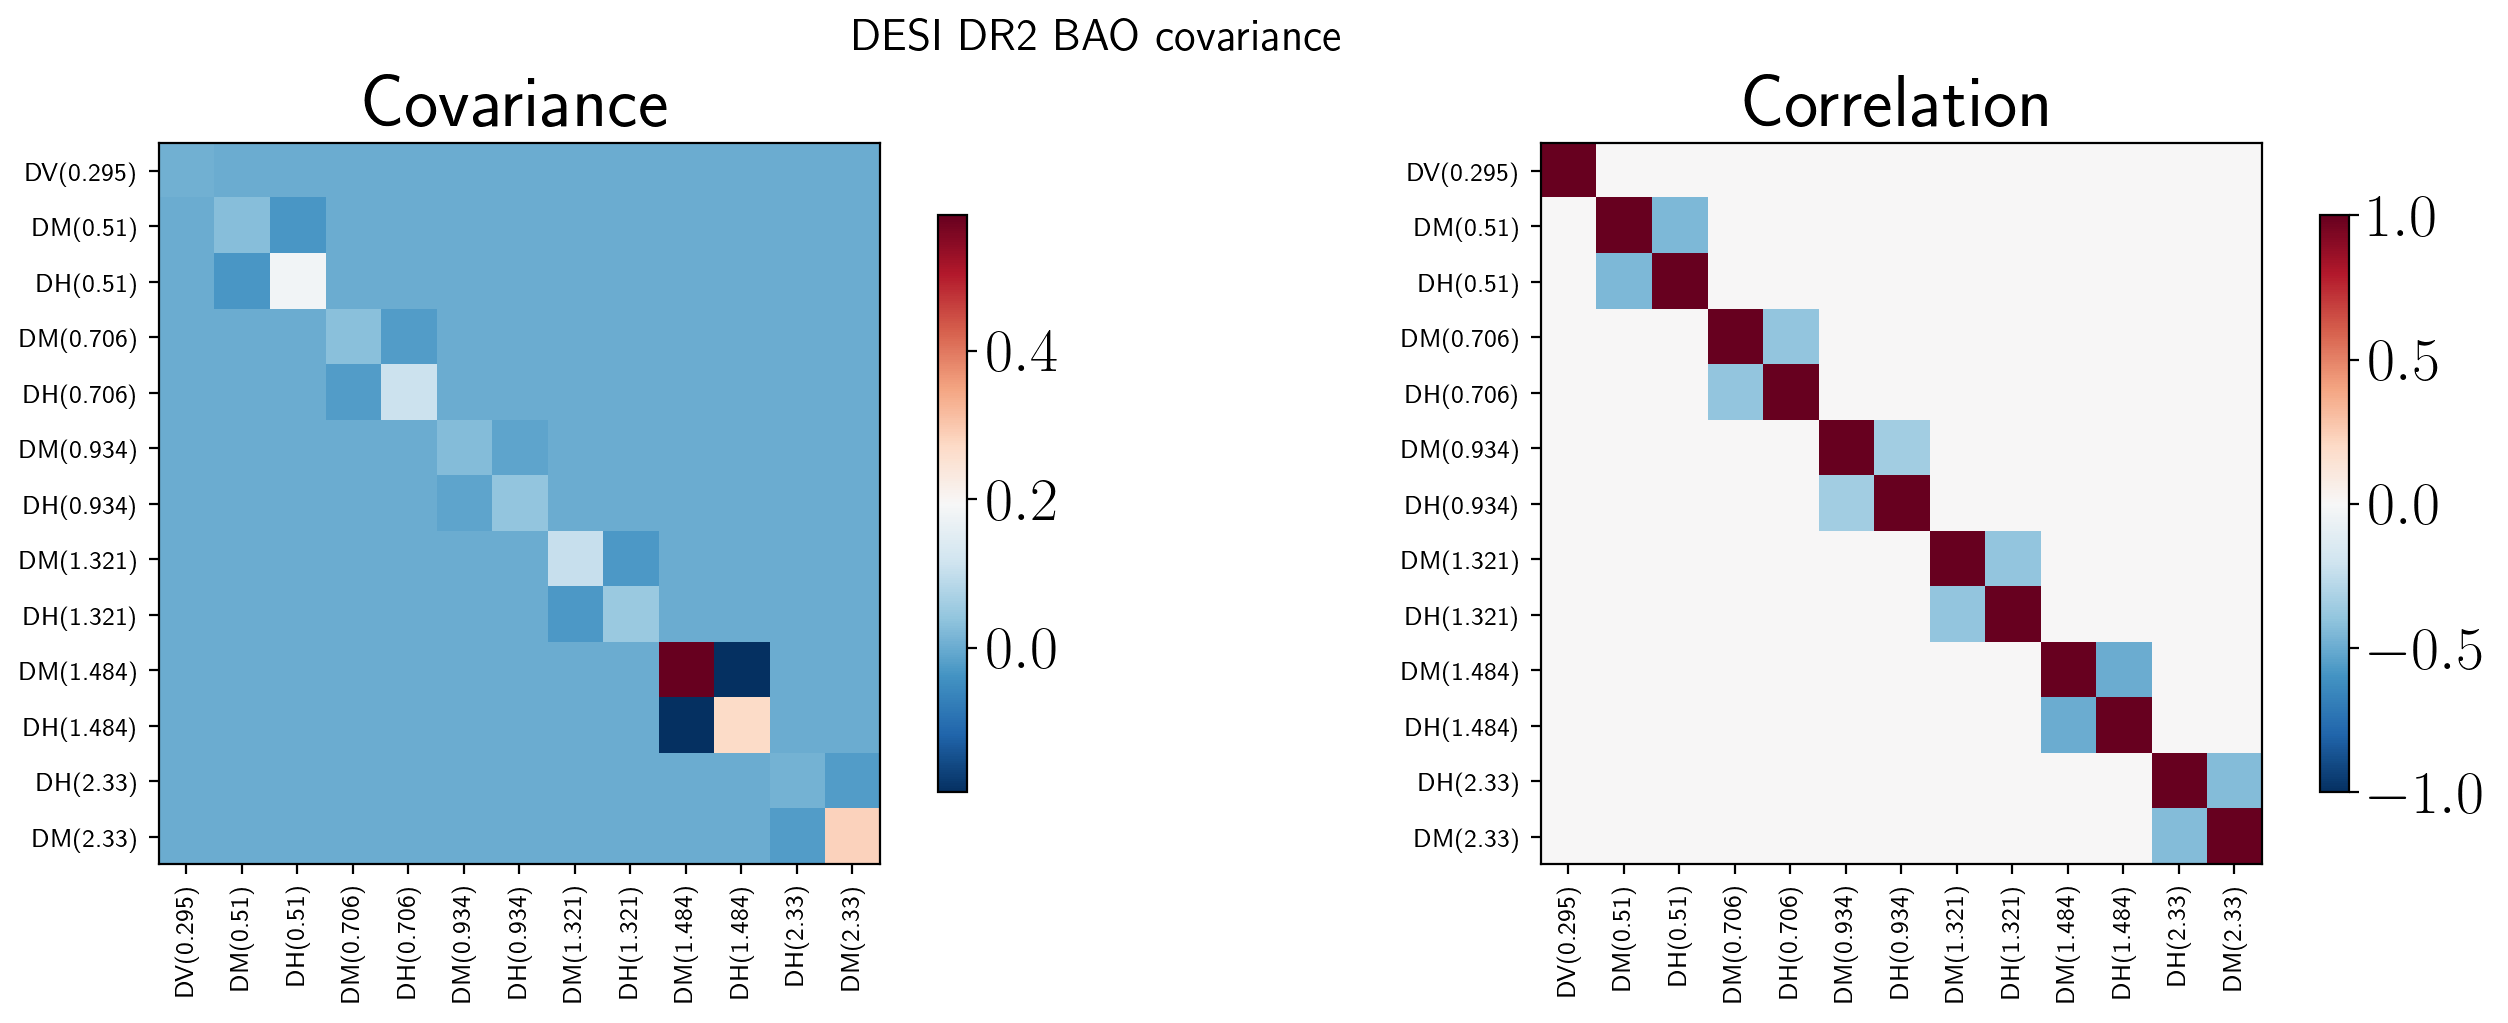

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Covariance
im1 = ax1.imshow(np.array(bao_dr2.cov), cmap='RdBu_r', aspect='equal')
ax1.set_title("Covariance")
plt.colorbar(im1, ax=ax1, shrink=0.8)

# Correlation matrix
sigma = np.sqrt(np.diag(bao_dr2.cov))
corr = np.array(bao_dr2.cov) / np.outer(sigma, sigma)
im2 = ax2.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
ax2.set_title("Correlation")
plt.colorbar(im2, ax=ax2, shrink=0.8)

# Labels
labels = [f"{dp.observable.split('_')[0]}({dp.z})" for dp in bao_dr2.data_points]
for ax in (ax1, ax2):
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)

fig.suptitle("DESI DR2 BAO covariance", fontsize=16)

## Fiducial cosmology

For flat $\Lambda$CDM, the BAO observables depend on three background parameters:
$h$, $\omega_b$, and $\omega_{cdm}$.  Neutrino mass is fixed at
$m_\nu = 0.06\,$eV (not varied).

In [4]:
# Fiducial cosmology (Planck 2018 best-fit)
cosmo_dict = {
    'ombh2': 0.02242,
    'omch2': 0.11933,
    'h':     0.6766,
}
cosmo = CosmoParams(cosmo_dict)
print(cosmo)

cosmo_keys  = cosmo.param_keys
cosmo_sizes = cosmo.param_sizes
fiducial_params = cosmo.to_array()

print(f"\nParameter keys:  {cosmo_keys}")
print(f"Parameter sizes: {cosmo_sizes}")
print(f"Packed array:    {fiducial_params}")

CosmoParams:
  ombh2: 0.02242
  omch2: 0.11933
  h: 0.6766

Parameter keys:  ('ombh2', 'omch2', 'h')
Parameter sizes: (1, 1, 1)
Packed array:    [0.02242 0.11933 0.6766 ]


## BAO theory prediction

Build a differentiable theory function `bao_fn(params) -> jnp.ndarray`
that computes $D_V/r_d$, $D_M/r_d$, and $D_H/r_d$ at each DESI redshift bin.

In [5]:
bao_fn = make_bao_theory_fn(
    bao_dr2,
    cosmo_keys=cosmo_keys,
    cosmo_sizes=cosmo_sizes,
    mnu_fixed=0.06,
)

# Evaluate at fiducial cosmology
theory_fid = bao_fn(fiducial_params)

print(f"{'z':>6s}  {'observable':>12s}  {'data':>12s}  {'theory':>12s}  {'(th-d)/d [%]':>12s}")
print("-" * 65)
for i, dp in enumerate(bao_dr2.data_points):
    pct = 100 * (float(theory_fid[i]) - dp.value) / dp.value
    print(f"{dp.z:6.3f}  {dp.observable:>12s}  {dp.value:12.6f}  {float(theory_fid[i]):12.6f}  {pct:+10.3f} %")

     z    observable          data        theory  (th-d)/d [%]
-----------------------------------------------------------------
 0.295    DV_over_rs      7.941676      8.026287      +1.065 %
 0.510    DM_over_rs     13.587584     13.452675      -0.993 %
 0.510    DH_over_rs     21.862947     22.692781      +3.796 %
 0.706    DM_over_rs     17.350691     17.645969      +1.702 %
 0.706    DH_over_rs     19.455349     20.144123      +3.540 %
 0.934    DM_over_rs     21.575640     21.936343      +1.672 %
 0.934    DH_over_rs     17.641495     17.560093      -0.461 %
 1.321    DM_over_rs     27.600856     28.022939      +1.529 %
 1.321    DH_over_rs     14.176022     14.069755      -0.750 %
 1.484    DM_over_rs     30.511901     30.217927      -0.963 %
 1.484    DH_over_rs     12.817000     12.887747      +0.552 %
 2.330    DH_over_rs      8.631546      8.627777      -0.044 %
 2.330    DM_over_rs     38.988974     39.133932      +0.372 %


## Jacobian $\partial d_i / \partial \theta_j$

Compute the Jacobian of the BAO data vector with respect to cosmological
parameters using `jax.jacfwd` (forward-mode automatic differentiation).

In [6]:
jac = jax.jacfwd(bao_fn)(fiducial_params)
print(f"Jacobian shape: {jac.shape}")
print(f"  rows = {jac.shape[0]} data points")
print(f"  cols = {jac.shape[1]} parameters ({cosmo_keys})")

# Display Jacobian as a table
print(f"\n{'':>30s}  {'d/d(ombh2)':>12s}  {'d/d(omch2)':>12s}  {'d/d(h)':>12s}")
print("-" * 72)
for i, dp in enumerate(bao_dr2.data_points):
    label = f"{dp.observable}(z={dp.z})"
    print(f"{label:>30s}  {float(jac[i, 0]):12.4f}  {float(jac[i, 1]):12.4f}  {float(jac[i, 2]):12.4f}")

Jacobian shape: (13, 3)
  rows = 13 data points
  cols = 3 parameters (('ombh2', 'omch2', 'h'))

                                  d/d(ombh2)    d/d(omch2)        d/d(h)
------------------------------------------------------------------------
           DV_over_rs(z=0.295)       55.2051        9.3564       -9.7589
            DM_over_rs(z=0.51)       90.6632       13.8173      -15.5718
            DH_over_rs(z=0.51)      135.8073        6.1791      -19.0578
           DM_over_rs(z=0.706)      114.8547       14.0555      -18.7131
           DH_over_rs(z=0.706)      112.0334       -3.0360      -13.3308
           DM_over_rs(z=0.934)      137.8846       12.5774      -21.2024
           DH_over_rs(z=0.934)       91.0333       -9.2754       -8.8306
           DM_over_rs(z=1.321)      168.0716        7.9958      -23.6880
           DH_over_rs(z=1.321)       66.9208      -13.4500       -4.5422
           DM_over_rs(z=1.484)      178.3734        5.7592      -24.3384
           DH_over_rs(z=1.4

## Fisher matrix

$$F_{ij} = J^T \, C^{-1} \, J$$

where $J_{di} = \partial d_d / \partial \theta_i$ and $C$ is the data covariance.

In [7]:
F_bao = fisher_matrix(bao_dr2.cov, jac)
print("BAO Fisher matrix:")
print(np.array(F_bao))

# Marginalized 1-sigma constraints (no priors)
sigma_bao = sigma_from_fisher(F_bao)
print(f"\nMarginalized 1-sigma (BAO only, no priors):")
for name, s, fid in zip(cosmo_keys, sigma_bao, fiducial_params):
    print(f"  {name:>8s}: {float(fid):.5f} +/- {float(s):.5f}  ({100*float(s)/float(fid):+.2f}%)")

BAO Fisher matrix:
[[4614503.44095242  173251.32695733 -636763.91395722]
 [ 173251.32695733   62575.1999979   -40389.51170035]
 [-636763.91395722  -40389.51170035   92713.28497331]]

Marginalized 1-sigma (BAO only, no priors):
     ombh2: 0.02242 +/- 28102.43489  (+125345383.08%)
     omch2: 0.11933 +/- 65069.12518  (+54528723.02%)
         h: 0.67660 +/- 221356.91372  (+32716067.65%)


## External priors: BBN

BAO alone cannot tightly constrain $\omega_b$ (it enters only through $r_d$).
Adding a BBN prior on $\omega_b$ is standard practice:

| Parameter | Prior | Source |
|-----------|-------|--------|
| $\omega_b$ | $\mathcal{N}(0.02218,\; 0.00055)$ | BBN (Schoeneberg 2024) |

In [8]:
n_params = len(fiducial_params)

# BBN prior on omega_b
prior_sigmas = {0: 0.00055}  # index 0 = ombh2
F_prior = gaussian_prior_fisher(n_params, prior_sigmas)

F_bao_bbn = F_bao + F_prior

sigma_bao_bbn = sigma_from_fisher(F_bao_bbn)
print("Marginalized 1-sigma (BAO + BBN prior):")
for name, s, fid in zip(cosmo_keys, sigma_bao_bbn, fiducial_params):
    print(f"  {name:>8s}: {float(fid):.5f} +/- {float(s):.5f}  ({100*float(s)/float(fid):+.2f}%)")

Marginalized 1-sigma (BAO + BBN prior):
     ombh2: 0.02242 +/- 0.00055  (+2.45%)
     omch2: 0.11933 +/- 0.00488  (+4.09%)
         h: 0.67660 +/- 0.00581  (+0.86%)


## Using the convenience function `bao_fisher_matrix`

The above steps (build theory, compute Jacobian, form Fisher) are wrapped
in a single function call.

In [9]:
# One-liner equivalent
F_check = bao_fisher_matrix(
    bao_dr2, fiducial_params,
    cosmo_keys=cosmo_keys,
    cosmo_sizes=cosmo_sizes,
    cosmo_priors={'ombh2': 0.00055},
)
print("Max difference from step-by-step:", float(jnp.max(jnp.abs(F_check - F_bao_bbn))))

Max difference from step-by-step: 2.9103830456733704e-10


## Fisher contours

Triangle plot of the marginalized 2-d constraints for ($\omega_b$, $\omega_{cdm}$, $h$),
comparing BAO-only with BAO + BBN prior.

Text(0.5, 1.02, 'DESI DR2 BAO Fisher forecast ($\\Lambda$CDM)')

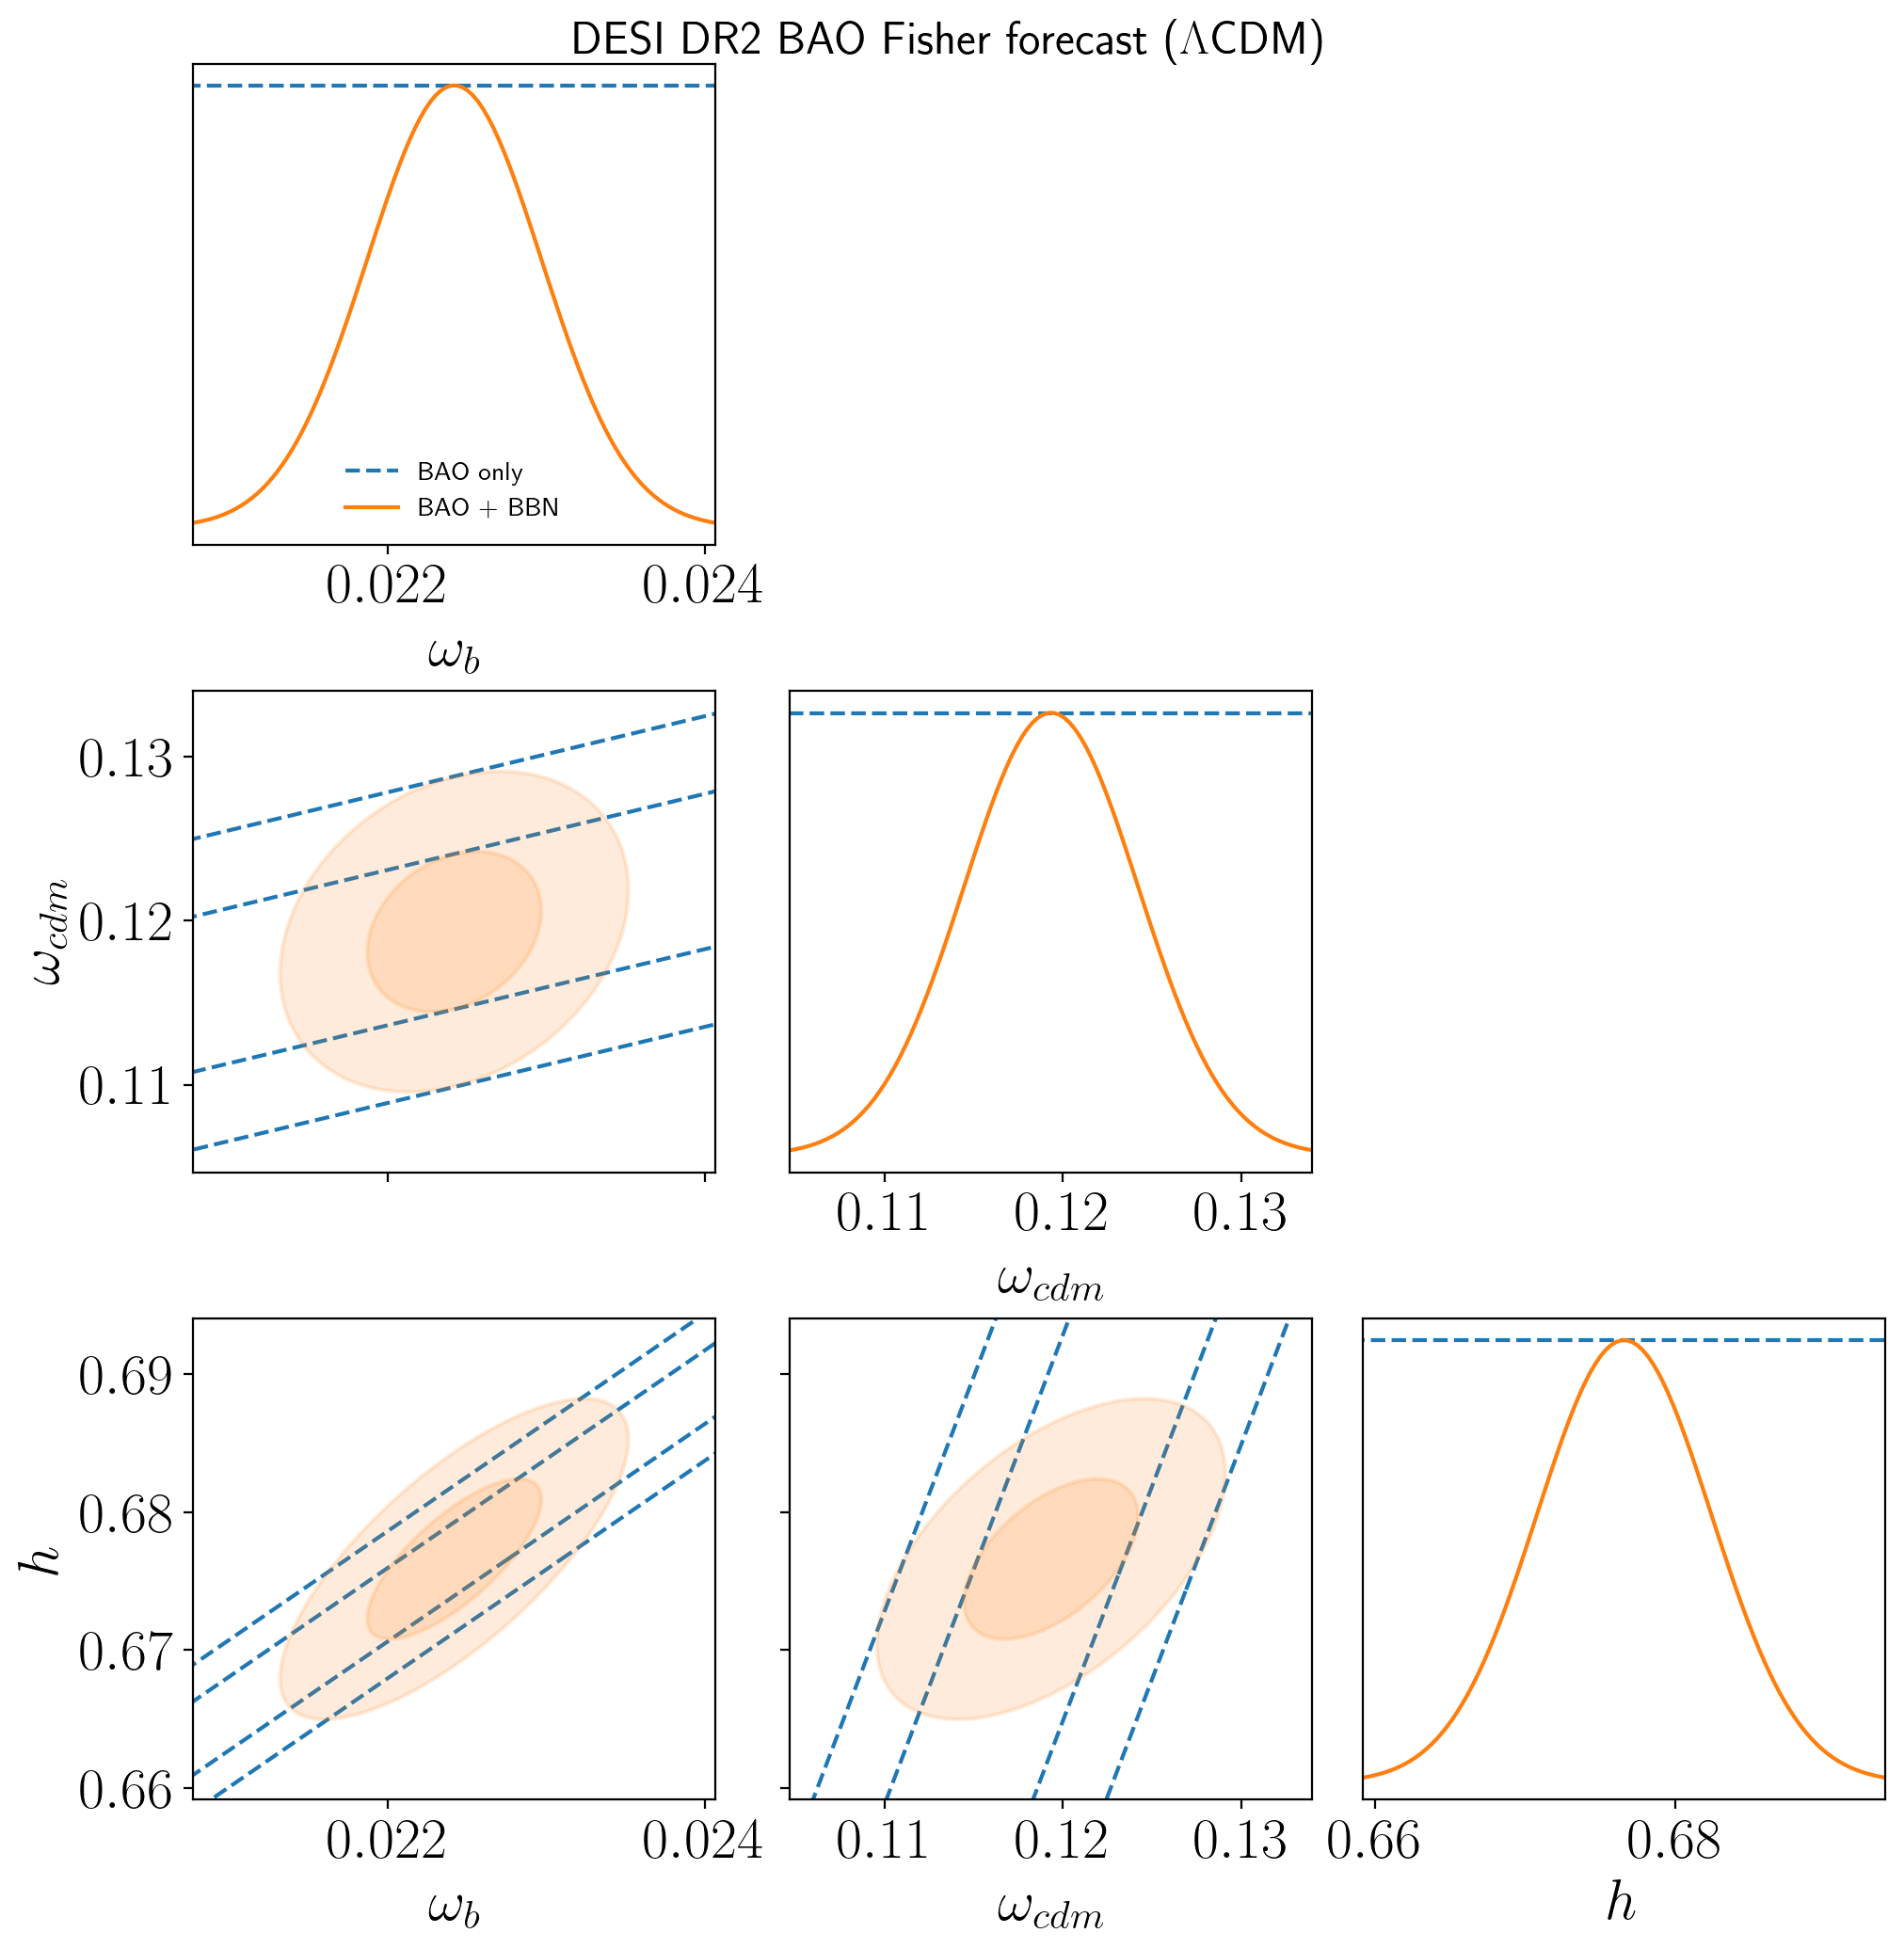

In [10]:
param_labels = (r'$\omega_b$', r'$\omega_{cdm}$', r'$h$')
n_plot = len(param_labels)
plot_idx = np.arange(n_plot)
fid_vals = np.array(fiducial_params)

fig, axes = plt.subplots(n_plot, n_plot, figsize=(10, 10), constrained_layout=True)

for i in range(n_plot):
    for j in range(n_plot):
        ax = axes[i, j]
        if j > i:
            ax.axis('off')
            continue
        if i == j:
            # 1-d marginal
            plot_Gaussian(F_bao, fid_vals, i, ax=ax, color='C0',
                          ls='--', label='BAO only')
            plot_Gaussian(F_bao_bbn, fid_vals, i, ax=ax, color='C1',
                          label='BAO + BBN')
            ax.set_xlabel(param_labels[i])
            ax.set_yticks([])
            if i == 0:
                ax.legend(fontsize=10, frameon=False)
        else:
            # 2-d contour
            plot_contours(F_bao, fid_vals, [j, i], ax=ax,
                          edgecolor='C0', ls='--', facecolor='none', lw=1.5)
            plot_contours(F_bao_bbn, fid_vals, [j, i], ax=ax,
                          edgecolor='C1', facecolor='C1', alpha=0.15, lw=1.5)
            if j == 0:
                ax.set_ylabel(param_labels[i])
            else:
                ax.set_yticklabels([])
            if i == n_plot - 1:
                ax.set_xlabel(param_labels[j])
            else:
                ax.set_xticklabels([])

fig.suptitle(r"DESI DR2 BAO Fisher forecast ($\Lambda$CDM)", fontsize=18, y=1.02)

## Comparison: DESI 2024 (DR1) vs DESI DR2

Load the DESI 2024 (DR1) data and compare the Fisher constraints.

In [11]:
bao_2024_dir = "../../ext_data/bao_data"
bao_2024 = load_desi_2024("all", data_dir=bao_2024_dir)

print(f"DESI 2024 (DR1): {len(bao_2024.data_points)} data points")
for dp in bao_2024.data_points:
    print(f"  z={dp.z:.3f}  {dp.value:12.6f}  {dp.observable}")

F_bao_2024 = bao_fisher_matrix(
    bao_2024, fiducial_params,
    cosmo_keys=cosmo_keys,
    cosmo_sizes=cosmo_sizes,
    cosmo_priors={'ombh2': 0.00055},
)

sigma_2024 = sigma_from_fisher(F_bao_2024)
sigma_dr2  = sigma_from_fisher(F_bao_bbn)

print(f"\n{'param':>8s}  {'sigma(DR1)':>12s}  {'sigma(DR2)':>12s}  {'improvement':>12s}")
print("-" * 50)
for name, s1, s2 in zip(cosmo_keys, sigma_2024, sigma_dr2):
    improv = 100 * (1 - float(s2) / float(s1))
    print(f"{name:>8s}  {float(s1):12.6f}  {float(s2):12.6f}  {improv:+10.1f} %")

DESI 2024 (DR1): 12 data points
  z=0.295      7.925129  DV_over_rs
  z=0.510     13.620031  DM_over_rs
  z=0.510     20.983346  DH_over_rs
  z=0.706     16.846453  DM_over_rs
  z=0.706     20.078729  DH_over_rs
  z=0.930     21.708418  DM_over_rs
  z=0.930     17.876129  DH_over_rs
  z=1.317     27.787208  DM_over_rs
  z=1.317     13.823723  DH_over_rs
  z=1.491     26.072172  DV_over_rs
  z=2.330     39.708383  DM_over_rs
  z=2.330      8.522566  DH_over_rs

   param    sigma(DR1)    sigma(DR2)   improvement
--------------------------------------------------
   ombh2      0.000550      0.000550        +0.0 %
   omch2      0.008144      0.004884       +40.0 %
       h      0.007882      0.005811       +26.3 %


Text(0.5, 1.02, 'DESI DR1 vs DR2 BAO + BBN ($\\Lambda$CDM)')

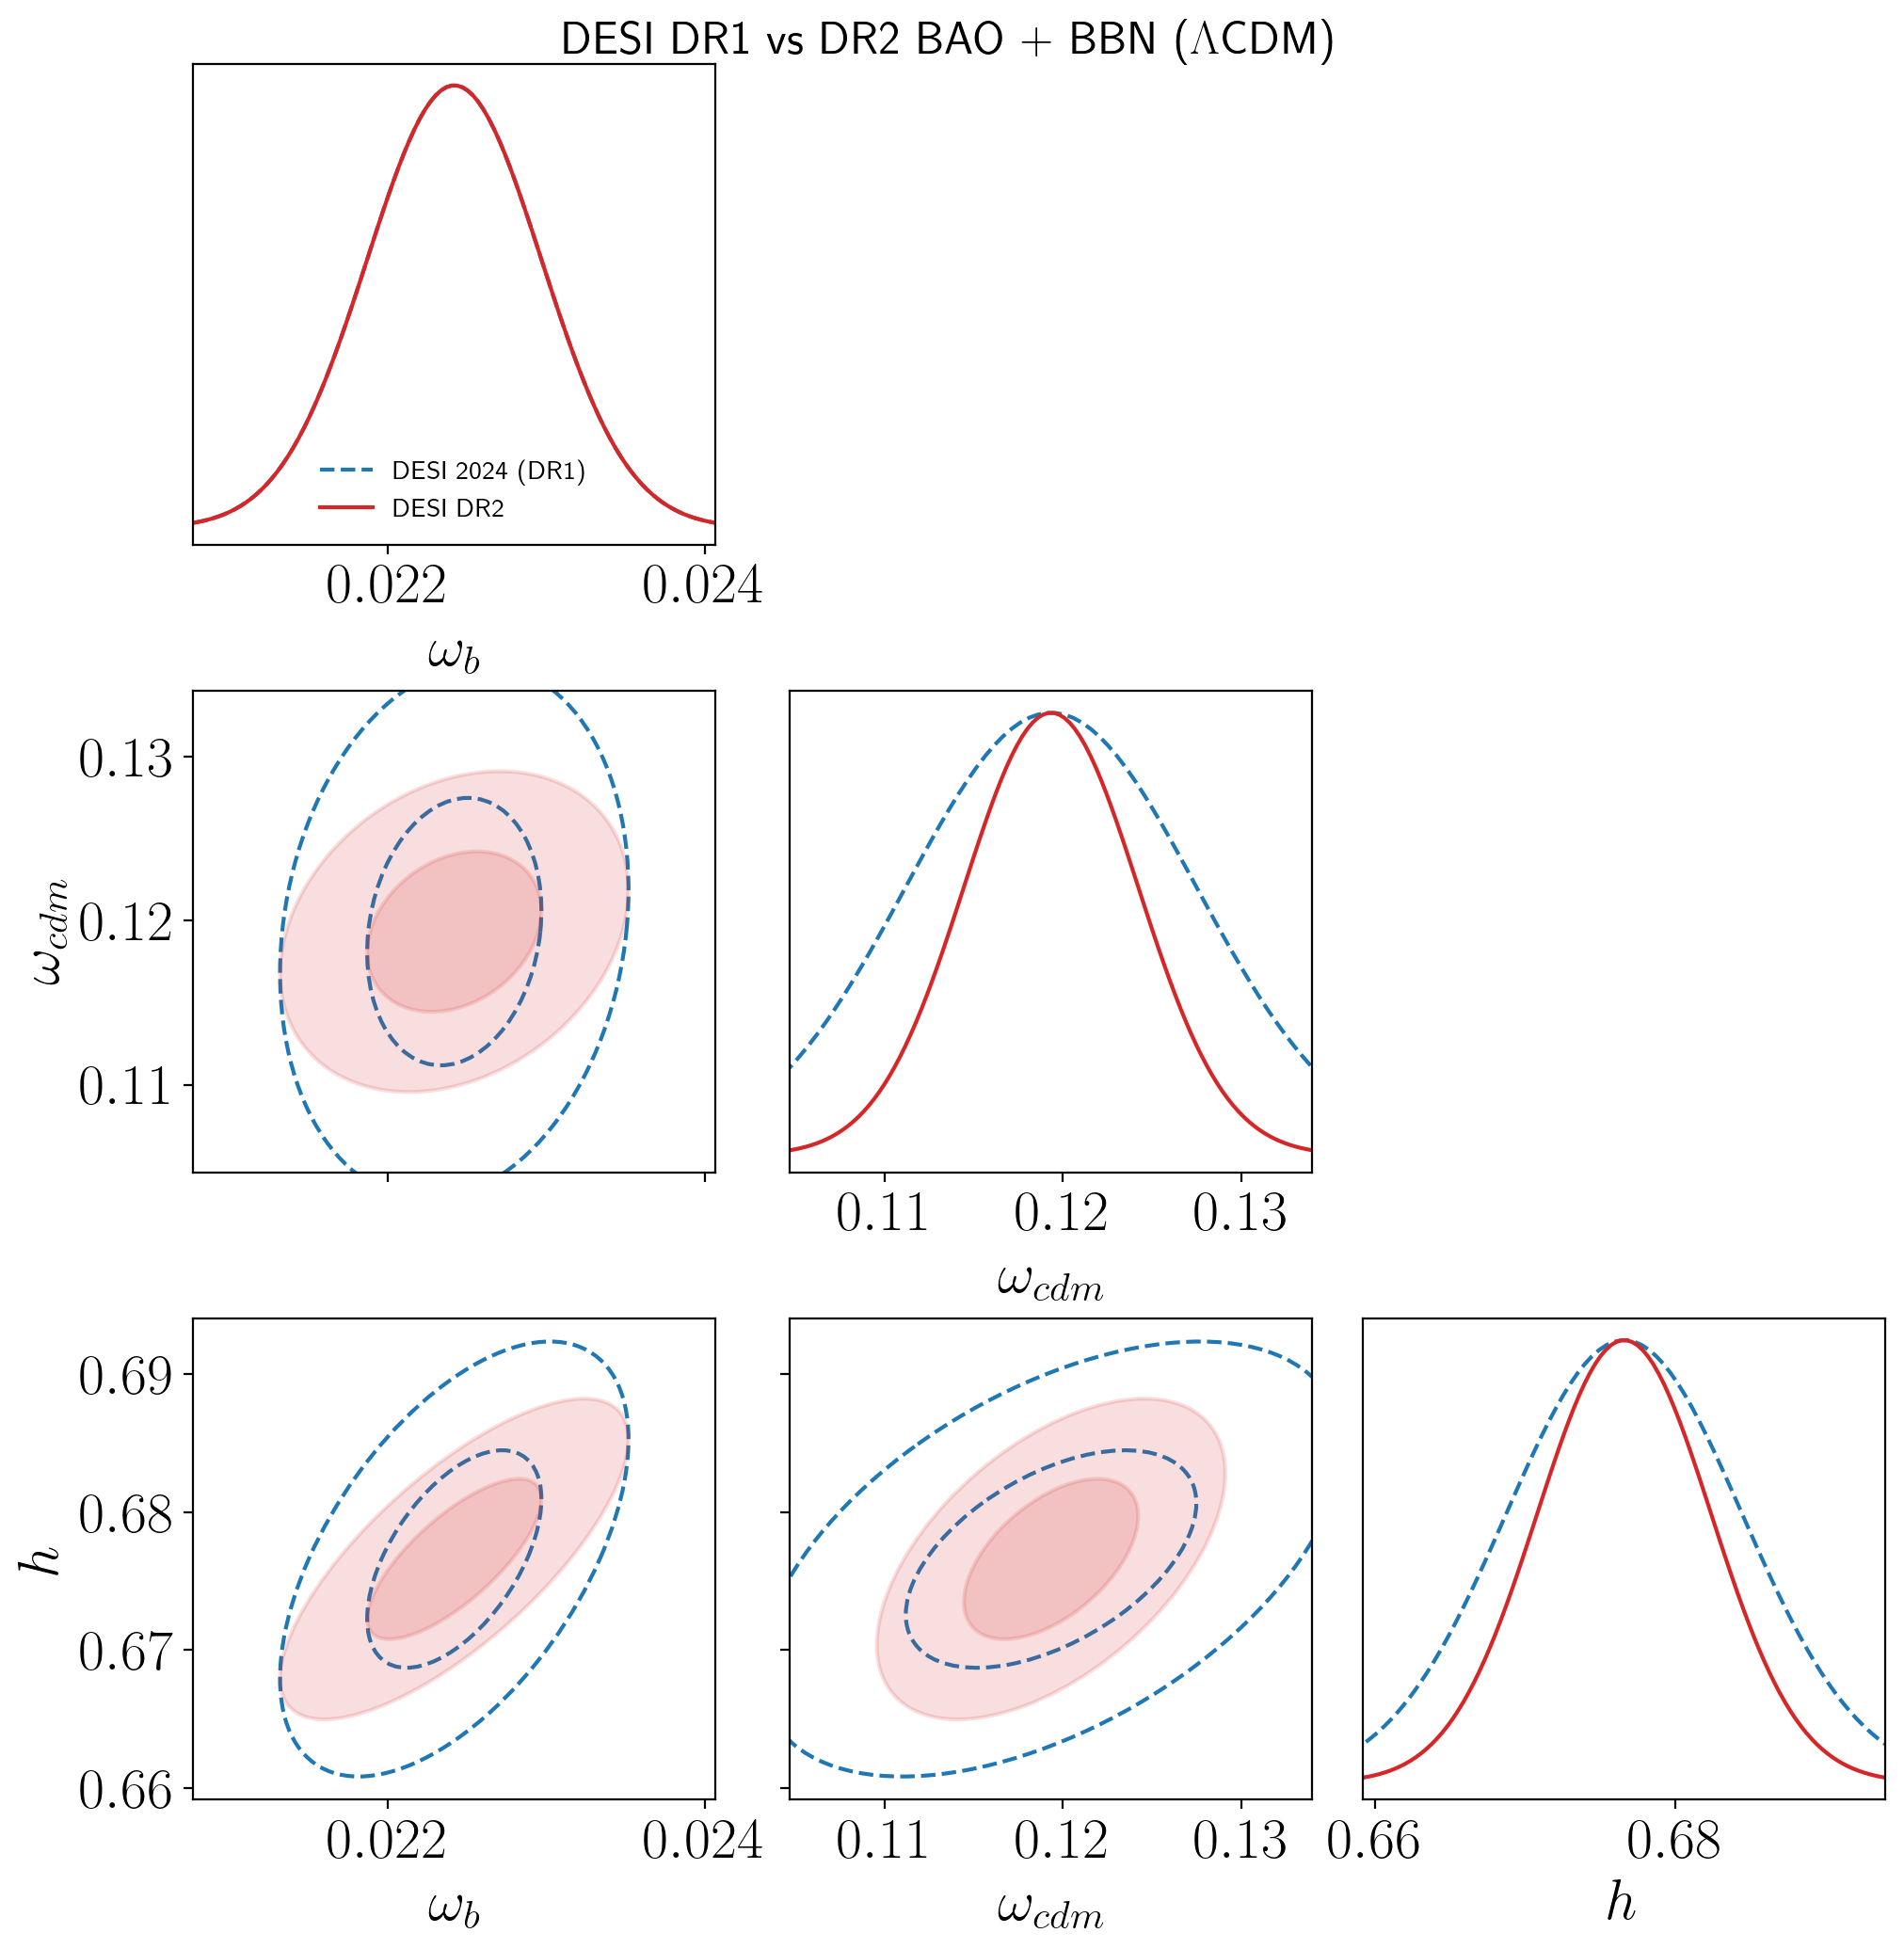

In [12]:
fig, axes = plt.subplots(n_plot, n_plot, figsize=(10, 10), constrained_layout=True)

for i in range(n_plot):
    for j in range(n_plot):
        ax = axes[i, j]
        if j > i:
            ax.axis('off')
            continue
        if i == j:
            plot_Gaussian(F_bao_2024, fid_vals, i, ax=ax, color='C0',
                          ls='--', label='DESI 2024 (DR1)')
            plot_Gaussian(F_bao_bbn, fid_vals, i, ax=ax, color='C3',
                          label='DESI DR2')
            ax.set_xlabel(param_labels[i])
            ax.set_yticks([])
            if i == 0:
                ax.legend(fontsize=10, frameon=False)
        else:
            plot_contours(F_bao_2024, fid_vals, [j, i], ax=ax,
                          edgecolor='C0', ls='--', facecolor='none', lw=1.5)
            plot_contours(F_bao_bbn, fid_vals, [j, i], ax=ax,
                          edgecolor='C3', facecolor='C3', alpha=0.15, lw=1.5)
            if j == 0:
                ax.set_ylabel(param_labels[i])
            else:
                ax.set_yticklabels([])
            if i == n_plot - 1:
                ax.set_xlabel(param_labels[j])
            else:
                ax.set_xticklabels([])

fig.suptitle(r"DESI DR1 vs DR2 BAO + BBN ($\Lambda$CDM)", fontsize=18, y=1.02)

## Per-tracer Fisher constraints

Compute the BAO Fisher matrix for each individual DESI DR2 tracer sample
and compare with the combined result.

In [13]:
tracer_names = ['bgs', 'lrg1', 'lrg2', 'lrg_elg', 'elg', 'qso', 'lya']
tracer_labels = ['BGS', 'LRG1', 'LRG2', 'LRG+ELG', 'ELG', 'QSO', r'Ly$\alpha$']

# Compute per-tracer Fisher matrices (with BBN prior)
F_per_tracer_dr2 = {}
for name in tracer_names:
    bao_t = load_desi_dr2(name, data_dir=bao_data_dir)
    F_t = bao_fisher_matrix(
        bao_t, fiducial_params,
        cosmo_keys=cosmo_keys, cosmo_sizes=cosmo_sizes,
        cosmo_priors={'ombh2': 0.00055},
    )
    F_per_tracer_dr2[name] = F_t

# Also per-tracer for DR1
F_per_tracer_2024 = {}
dr1_tracers = ['bgs', 'lrg1', 'lrg2', 'lrg_elg', 'elg', 'qso', 'lya']
for name in dr1_tracers:
    bao_t = load_desi_2024(name, data_dir=bao_2024_dir)
    F_t = bao_fisher_matrix(
        bao_t, fiducial_params,
        cosmo_keys=cosmo_keys, cosmo_sizes=cosmo_sizes,
        cosmo_priors={'ombh2': 0.00055},
    )
    F_per_tracer_2024[name] = F_t

# Print comparison table
print(f"{'Tracer':>10s}  {'sigma(h) DR1':>14s}  {'sigma(h) DR2':>14s}  {'improv.':>8s}")
print("-" * 52)
for name, label in zip(tracer_names, tracer_labels):
    s1 = float(sigma_from_fisher(F_per_tracer_2024[name])[2])
    s2 = float(sigma_from_fisher(F_per_tracer_dr2[name])[2])
    improv = 100 * (1 - s2 / s1)
    print(f"{label:>10s}  {s1:14.5f}  {s2:14.5f}  {improv:+6.1f} %")

# Combined
s1_all = float(sigma_from_fisher(F_bao_2024)[2])
s2_all = float(sigma_from_fisher(F_bao_bbn)[2])
improv_all = 100 * (1 - s2_all / s1_all)
print(f"{'ALL':>10s}  {s1_all:14.5f}  {s2_all:14.5f}  {improv_all:+6.1f} %")

    Tracer    sigma(h) DR1    sigma(h) DR2   improv.
----------------------------------------------------
       BGS   1096570.79792             nan    +nan %
      LRG1         0.05545         0.03891   +29.8 %
      LRG2         0.03308         0.01895   +42.7 %
   LRG+ELG         0.01412         0.00907   +35.8 %
       ELG         0.02391         0.01209   +49.4 %
       QSO             nan         0.02687    +nan %
Ly$\alpha$         0.03871         0.02208   +43.0 %
       ALL         0.00788         0.00581   +26.3 %


In [14]:
# Full per-tracer table: all three parameters
print("DESI DR2 per-tracer marginalized 1-sigma (with BBN prior on ombh2)")
print(f"\n{'Tracer':>10s}  {'sigma(ombh2)':>14s}  {'sigma(omch2)':>14s}  {'sigma(h)':>14s}")
print("-" * 58)
for name, label in zip(tracer_names, tracer_labels):
    s = sigma_from_fisher(F_per_tracer_dr2[name])
    print(f"{label:>10s}  {float(s[0]):14.6f}  {float(s[1]):14.6f}  {float(s[2]):14.6f}")
s_all = sigma_from_fisher(F_bao_bbn)
print(f"{'ALL':>10s}  {float(s_all[0]):14.6f}  {float(s_all[1]):14.6f}  {float(s_all[2]):14.6f}")

DESI DR2 per-tracer marginalized 1-sigma (with BBN prior on ombh2)

    Tracer    sigma(ombh2)    sigma(omch2)        sigma(h)
----------------------------------------------------------
       BGS        0.000550             nan             nan
      LRG1        0.000550        0.051579        0.038915
      LRG2        0.000550        0.030845        0.018950
   LRG+ELG        0.000550        0.016116        0.009069
       ELG        0.000550        0.017119        0.012086
       QSO        0.000550        0.039373        0.026866
Ly$\alpha$        0.000550        0.009301        0.022076
       ALL        0.000550        0.004884        0.005811


Skipped singular/NaN per-tracer constraints: BGS


Text(0.5, 0.98, 'DESI DR2 per-tracer BAO + BBN: $H_0 r_d$ vs $\\Omega_M$')

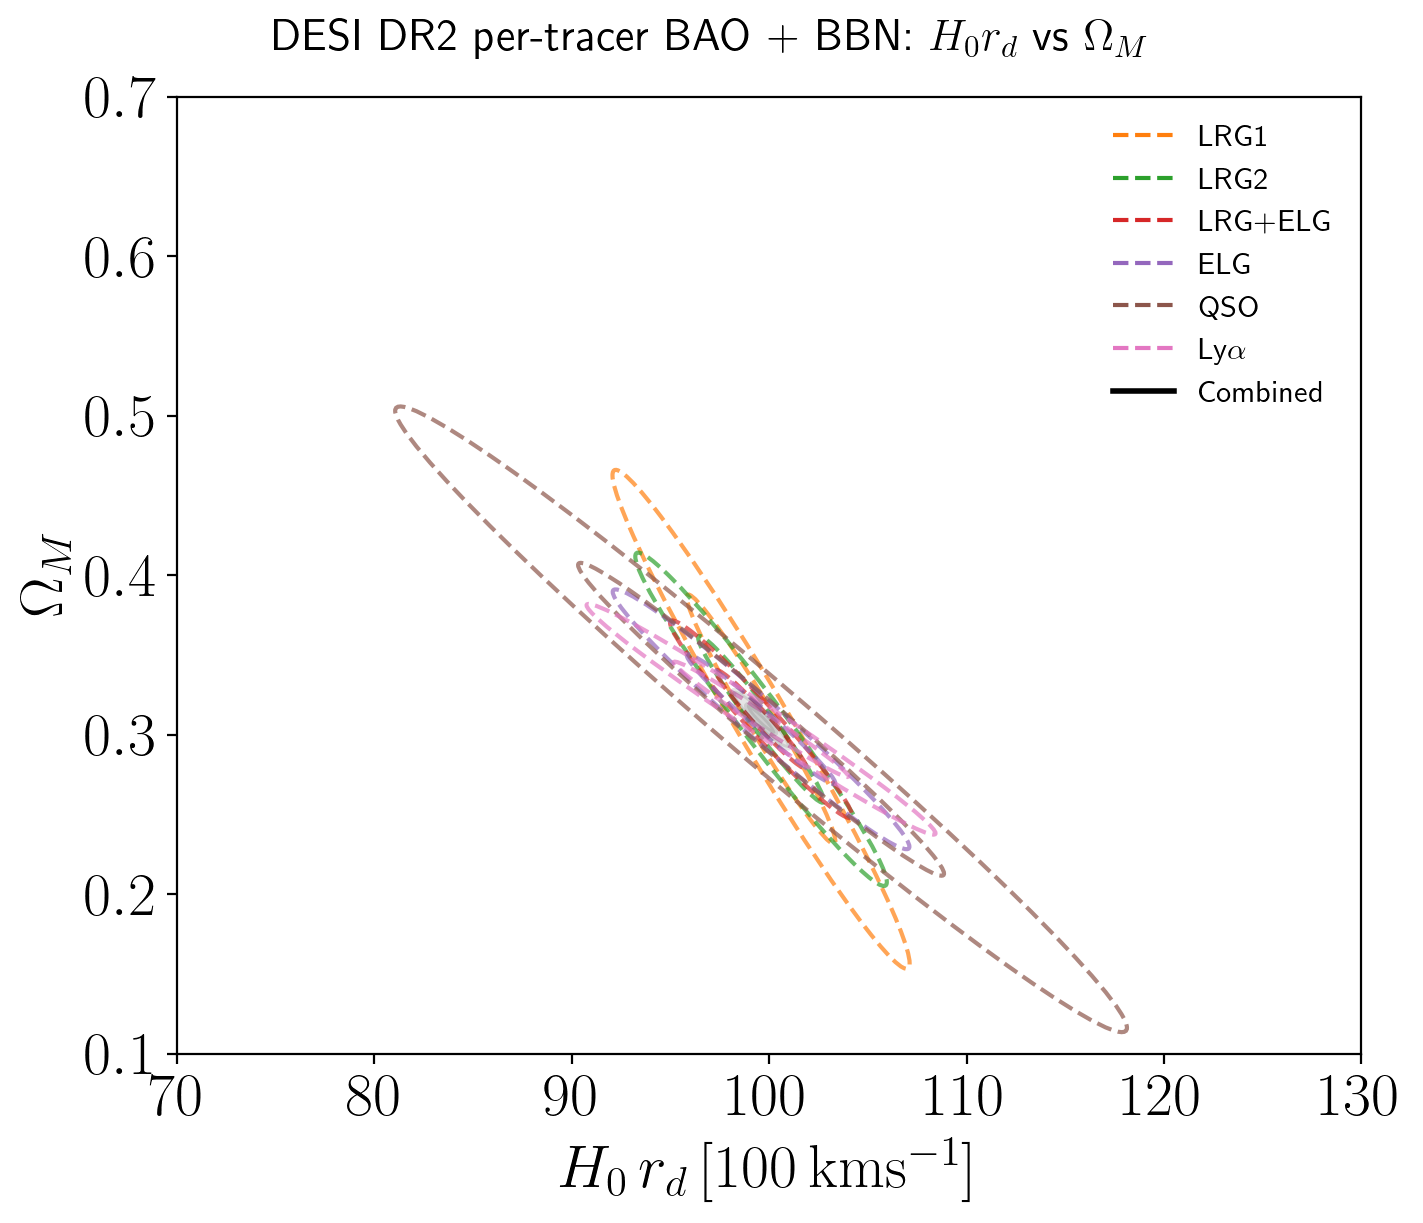

In [15]:
# Per-tracer contour plot in the derived (H0*r_d, Omega_m) plane for DR2
from jax.scipy.linalg import inv as jinv
from ps_1loop_jax import background as bg
import matplotlib.lines as mlines

def derived_Omega_m(params):
    ombh2, omch2, h = params[0], params[1], params[2]
    return (ombh2 + omch2) / h**2

def derived_H0_rd(params):
    ombh2, omch2, h = params[0], params[1], params[2]
    rd = bg.sound_horizon_drag(ombh2, omch2, h, mnu=0.06)
    return  h * rd

jac_H0rd = np.array(jax.jacfwd(derived_H0_rd)(fiducial_params))
jac_Om = np.array(jax.jacfwd(derived_Omega_m)(fiducial_params))
J_derived = np.vstack([jac_H0rd, jac_Om])
fid_vals_derived = np.array([
    float(derived_H0_rd(fiducial_params)),
    float(derived_Omega_m(fiducial_params)),
])

def fisher_to_derived_plane(F, J):
    cov = np.array(jinv(F), dtype=float)
    if not np.all(np.isfinite(cov)):
        return None
    cov_derived = J @ cov @ J.T
    if not np.all(np.isfinite(cov_derived)):
        return None
    eigvals = np.linalg.eigvalsh(cov_derived)
    if np.any(~np.isfinite(eigvals)) or np.any(eigvals <= 0.0):
        return None
    F_derived = np.linalg.inv(cov_derived)
    if not np.all(np.isfinite(F_derived)):
        return None
    return F_derived

colors_tracers = plt.cm.tab10(np.arange(len(tracer_names)))
valid_tracers = []
skipped_tracers = []

for color, name, label in zip(colors_tracers, tracer_names, tracer_labels):
    F_derived = fisher_to_derived_plane(F_per_tracer_dr2[name], J_derived)
    if F_derived is None:
        skipped_tracers.append(label)
        continue
    valid_tracers.append((F_derived, color, label))

F_combined_derived = fisher_to_derived_plane(F_bao_bbn, J_derived)
if F_combined_derived is None:
    raise ValueError("Combined DR2 Fisher matrix is singular in the derived (H0*r_d, Omega_m) plane.")

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

for F_derived, color, label in valid_tracers:
    plot_contours(F_derived, fid_vals_derived, [0, 1], ax=ax,
                  edgecolor=color, facecolor='none', ls='--', lw=1.5, alpha=0.7)

plot_contours(F_combined_derived, fid_vals_derived, [0, 1], ax=ax,
              edgecolor='k', facecolor='k', alpha=0.1, lw=2)

ax.set_xlabel(r'$H_0\,r_d\,[100\,\mathrm{kms^{-1}}]$')
ax.set_ylabel(r'$\Omega_M$')
ax.set_xlim(70.,130.)
ax.set_ylim(0.1,0.7)

handles = [mlines.Line2D([], [], color=color, ls='--', lw=1.5, label=label)
           for _, color, label in valid_tracers]
handles.append(mlines.Line2D([], [], color='k', lw=2, label='Combined'))
ax.legend(handles=handles, fontsize=11, frameon=False, loc='best')

if skipped_tracers:
    print("Skipped singular/NaN per-tracer constraints:", ", ".join(skipped_tracers))

fig.suptitle(r"DESI DR2 per-tracer BAO + BBN: $H_0 r_d$ vs $\Omega_M$", fontsize=16)

## Comparison with published DESI constraints

Compare our Fisher forecast with the reported MCMC constraints from the
DESI BAO papers.

**DR1** ([arXiv:2404.03002](https://arxiv.org/abs/2404.03002), Table 3):
- BAO alone: $\Omega_m = 0.295 \pm 0.015$, $r_d h = 101.8 \pm 1.3\,$Mpc
- BAO + BBN: $H_0 = 68.53 \pm 0.80\,$km/s/Mpc

**DR2** ([arXiv:2503.14738](https://arxiv.org/abs/2503.14738), Eqs. 17, 19):
- BAO alone: $\Omega_m = 0.2975 \pm 0.0086$, $h r_d = 101.54 \pm 0.73\,$Mpc
- BAO + BBN: $H_0 = 68.51 \pm 0.58\,$km/s/Mpc

Note: Fisher forecasts give the **Cramer-Rao lower bound** on parameter
uncertainties under a Gaussian approximation. They should agree well with
MCMC for BAO (which is close to Gaussian), but differences arise from:
- Our use of an analytic $r_d$ fitting function (Aubourg+ 2015)
  vs the full Boltzmann-code sound horizon
- The Fisher linearisation at the fiducial point
- The MCMC posterior may be non-Gaussian for some parameters

In [16]:
from jax.scipy.linalg import inv as jinv
from ps_1loop_jax import background as bg

# -------------------------------------------------------------------
# Derived parameters: Omega_m, h*rd, H0  (from ombh2, omch2, h)
# -------------------------------------------------------------------
def derived_Omega_m(params):
    ombh2, omch2, h = params[0], params[1], params[2]
    return (ombh2 + omch2) / h**2

def derived_h_rd(params):
    ombh2, omch2, h = params[0], params[1], params[2]
    rd = bg.sound_horizon_drag(ombh2, omch2, h, mnu=0.06)
    return h * rd

def derived_H0(params):
    return params[2] * 100.0

# Jacobians for each derived parameter
jac_Om  = jax.jacfwd(derived_Omega_m)(fiducial_params)
jac_hrd = jax.jacfwd(derived_h_rd)(fiducial_params)
jac_H0  = jax.jacfwd(derived_H0)(fiducial_params)

# Fiducial values
Om_fid  = float(derived_Omega_m(fiducial_params))
hrd_fid = float(derived_h_rd(fiducial_params))
H0_fid  = float(derived_H0(fiducial_params))

print(f"Fiducial derived parameters:")
print(f"  Omega_m = {Om_fid:.5f}")
print(f"  h*rd    = {hrd_fid:.2f} Mpc")
print(f"  H0      = {H0_fid:.2f} km/s/Mpc")

Fiducial derived parameters:
  Omega_m = 0.30964
  h*rd    = 99.58 Mpc
  H0      = 67.66 km/s/Mpc


In [17]:
# -------------------------------------------------------------------
# Propagate to derived parameter sigma  via:  sigma^2 = J^T F^{-1} J
# -------------------------------------------------------------------
def derived_sigma(F, jac_derived):
    """sigma of a derived parameter from Fisher matrix + Jacobian."""
    cov = jinv(F)
    return float(jnp.sqrt(jac_derived @ cov @ jac_derived))

# --- BAO alone (no prior) ---
sig_Om_dr2_noprior  = derived_sigma(F_bao, jac_Om)
sig_hrd_dr2_noprior = derived_sigma(F_bao, jac_hrd)

sig_Om_dr1_noprior  = derived_sigma(
    bao_fisher_matrix(bao_2024, fiducial_params,
                      cosmo_keys=cosmo_keys, cosmo_sizes=cosmo_sizes),
    jac_Om)
sig_hrd_dr1_noprior = derived_sigma(
    bao_fisher_matrix(bao_2024, fiducial_params,
                      cosmo_keys=cosmo_keys, cosmo_sizes=cosmo_sizes),
    jac_hrd)

# --- BAO + BBN prior ---
sig_Om_dr2  = derived_sigma(F_bao_bbn, jac_Om)
sig_hrd_dr2 = derived_sigma(F_bao_bbn, jac_hrd)
sig_H0_dr2  = derived_sigma(F_bao_bbn, jac_H0)

sig_Om_dr1  = derived_sigma(F_bao_2024, jac_Om)
sig_hrd_dr1 = derived_sigma(F_bao_2024, jac_hrd)
sig_H0_dr1  = derived_sigma(F_bao_2024, jac_H0)

# -------------------------------------------------------------------
# Print comparison table
# -------------------------------------------------------------------
print("=" * 85)
print("  Comparison of Fisher forecast vs published DESI MCMC (flat LCDM)")
print("=" * 85)
print()

# BAO alone
print("BAO alone (no external priors)")
print(f"{'':>20s}  {'Omega_m':>10s}  {'h*rd [Mpc]':>12s}")
print("-" * 48)
print(f"{'DR1 Fisher':>20s}  {sig_Om_dr1_noprior:10.4f}  {sig_hrd_dr1_noprior:12.2f}")
print(f"{'DR1 DESI paper':>20s}  {'0.0150':>10s}  {'1.30':>12s}")
print(f"{'DR2 Fisher':>20s}  {sig_Om_dr2_noprior:10.4f}  {sig_hrd_dr2_noprior:12.2f}")
print(f"{'DR2 DESI paper':>20s}  {'0.0086':>10s}  {'0.73':>12s}")

print()

# BAO + BBN
print("BAO + BBN prior (sigma(ombh2) = 0.00055)")
print(f"{'':>20s}  {'Omega_m':>10s}  {'H0 [km/s/Mpc]':>15s}")
print("-" * 50)
print(f"{'DR1 Fisher':>20s}  {sig_Om_dr1:10.4f}  {sig_H0_dr1:15.2f}")
print(f"{'DR1 DESI paper':>20s}  {'0.015':>10s}  {'0.80':>15s}")
print(f"{'DR2 Fisher':>20s}  {sig_Om_dr2:10.4f}  {sig_H0_dr2:15.2f}")
print(f"{'DR2 DESI paper':>20s}  {'0.0086':>10s}  {'0.58':>15s}")

  Comparison of Fisher forecast vs published DESI MCMC (flat LCDM)

BAO alone (no external priors)
                         Omega_m    h*rd [Mpc]
------------------------------------------------
          DR1 Fisher         nan          1.68
      DR1 DESI paper      0.0150          1.30
          DR2 Fisher    920.7508          0.63
      DR2 DESI paper      0.0086          0.73

BAO + BBN prior (sigma(ombh2) = 0.00055)
                         Omega_m    H0 [km/s/Mpc]
--------------------------------------------------
          DR1 Fisher      0.0154             0.79
      DR1 DESI paper       0.015             0.80
          DR2 Fisher      0.0089             0.58
      DR2 DESI paper      0.0086             0.58


### Per-tracer measurement precision: data file vs published

Compare the measurement uncertainties from the Gaussian data files
(square root of diagonal covariance elements) with the published
values from the DESI papers.

In [18]:
# Published 1-sigma uncertainties from the DESI papers
# DR1: Table 1 of arXiv:2404.03002
# DR2: Table IV of arXiv:2503.14738

dr1_published = {
    # (z, observable): sigma_published
    (0.295, 'DV_over_rs'): 0.15,
    (0.510, 'DM_over_rs'): 0.25,
    (0.510, 'DH_over_rs'): 0.61,
    (0.706, 'DM_over_rs'): 0.32,
    (0.706, 'DH_over_rs'): 0.60,
    (0.930, 'DM_over_rs'): 0.28,
    (0.930, 'DH_over_rs'): 0.35,
    (1.317, 'DM_over_rs'): 0.69,
    (1.317, 'DH_over_rs'): 0.42,
    (1.491, 'DV_over_rs'): 0.67,
    (2.330, 'DM_over_rs'): 0.94,
    (2.330, 'DH_over_rs'): 0.17,
}

dr2_published = {
    (0.295, 'DV_over_rs'): 0.075,
    (0.510, 'DM_over_rs'): 0.167,
    (0.510, 'DH_over_rs'): 0.425,
    (0.706, 'DM_over_rs'): 0.177,
    (0.706, 'DH_over_rs'): 0.330,
    (0.934, 'DM_over_rs'): 0.152,
    (0.934, 'DH_over_rs'): 0.193,
    (1.321, 'DM_over_rs'): 0.318,
    (1.321, 'DH_over_rs'): 0.221,
    (1.484, 'DM_over_rs'): 0.760,
    (1.484, 'DH_over_rs'): 0.516,
    (2.330, 'DH_over_rs'): 0.101,
    (2.330, 'DM_over_rs'): 0.531,
}

# Compare with our data-file diagonal errors
print("DESI DR1: sqrt(diag(cov)) vs published sigma")
print(f"{'z':>6s}  {'observable':>12s}  {'value':>10s}  {'file sigma':>12s}  {'paper sigma':>13s}  {'pct prec':>10s}")
print("-" * 70)
for dp in bao_2024.data_points:
    sig_file = float(jnp.sqrt(bao_2024.cov[
        bao_2024.data_points.index(dp), bao_2024.data_points.index(dp)]))
    key = (dp.z, dp.observable)
    sig_pub = dr1_published.get(key, None)
    pct = 100 * sig_file / dp.value
    pub_str = f"{sig_pub:.3f}" if sig_pub else "N/A"
    print(f"{dp.z:6.3f}  {dp.observable:>12s}  {dp.value:10.4f}  {sig_file:12.4f}  {pub_str:>13s}  {pct:8.2f} %")

print()
print("DESI DR2: sqrt(diag(cov)) vs published sigma")
print(f"{'z':>6s}  {'observable':>12s}  {'value':>10s}  {'file sigma':>12s}  {'paper sigma':>13s}  {'pct prec':>10s}")
print("-" * 70)
for dp in bao_dr2.data_points:
    idx = bao_dr2.data_points.index(dp)
    sig_file = float(jnp.sqrt(bao_dr2.cov[idx, idx]))
    key = (dp.z, dp.observable)
    sig_pub = dr2_published.get(key, None)
    pct = 100 * sig_file / dp.value
    pub_str = f"{sig_pub:.3f}" if sig_pub else "N/A"
    print(f"{dp.z:6.3f}  {dp.observable:>12s}  {dp.value:10.4f}  {sig_file:12.4f}  {pub_str:>13s}  {pct:8.2f} %")

DESI DR1: sqrt(diag(cov)) vs published sigma
     z    observable       value    file sigma    paper sigma    pct prec
----------------------------------------------------------------------
 0.295    DV_over_rs      7.9251        0.1507          0.150      1.90 %
 0.510    DM_over_rs     13.6200        0.2519          0.250      1.85 %
 0.510    DH_over_rs     20.9833        0.6107          0.610      2.91 %
 0.706    DM_over_rs     16.8465        0.3193          0.320      1.90 %
 0.706    DH_over_rs     20.0787        0.5954          0.600      2.97 %
 0.930    DM_over_rs     21.7084        0.2821          0.280      1.30 %
 0.930    DH_over_rs     17.8761        0.3463          0.350      1.94 %
 1.317    DM_over_rs     27.7872        0.6903          0.690      2.48 %
 1.317    DH_over_rs     13.8237        0.4222          0.420      3.05 %
 1.491    DV_over_rs     26.0722        0.6687          0.670      2.56 %
 2.330    DM_over_rs     39.7084        0.9433          0.940      2.3

## Derived parameter: $\Omega_m$

We can propagate the Fisher constraints to a derived parameter like the
total matter density $\Omega_m = (\omega_b + \omega_{cdm}) / h^2$ using
the Jacobian of the transformation.

In [19]:
# Omega_m = (ombh2 + omch2) / h^2
def Omega_m(params):
    ombh2, omch2, h = params[0], params[1], params[2]
    return (ombh2 + omch2) / h**2

Om_fid = Omega_m(fiducial_params)
print(f"Fiducial Omega_m = {float(Om_fid):.5f}")

# Jacobian of Omega_m w.r.t. (ombh2, omch2, h)
jac_Om = jax.jacfwd(Omega_m)(fiducial_params)  # shape (3,)
print(f"d(Omega_m)/d(params) = {np.array(jac_Om)}")

# sigma(Omega_m) = sqrt( J^T F^{-1} J )
from jax.scipy.linalg import inv
cov_bao_bbn = inv(F_bao_bbn)
sigma_Om = jnp.sqrt(jac_Om @ cov_bao_bbn @ jac_Om)

cov_2024 = inv(F_bao_2024)
sigma_Om_2024 = jnp.sqrt(jac_Om @ cov_2024 @ jac_Om)

print(f"\nsigma(Omega_m):")
print(f"  DESI 2024 (DR1) + BBN: {float(sigma_Om_2024):.5f}")
print(f"  DESI DR2 + BBN:        {float(sigma_Om):.5f}")
print(f"  Improvement:           {100*(1 - float(sigma_Om)/float(sigma_Om_2024)):+.1f} %")

Fiducial Omega_m = 0.30964
d(Omega_m)/d(params) = [ 2.18441934  2.18441934 -0.91528655]

sigma(Omega_m):
  DESI 2024 (DR1) + BBN: 0.01535
  DESI DR2 + BBN:        0.00894
  Improvement:           +41.8 %


## Summary

This notebook demonstrates the full BAO Fisher forecast pipeline using
DESI DR1 and DR2 data:

1. **Data loading**: `load_desi_dr2()` / `load_desi_2024()` read the
   cobaya-format measurement + covariance files
2. **Theory**: `make_bao_theory_fn()` builds a JAX-differentiable
   closure computing $D_V/r_d$, $D_M/r_d$, $D_H/r_d$
3. **Fisher matrix**: `bao_fisher_matrix()` computes $F = J^T C^{-1} J$
   via `jax.jacfwd` + Cholesky solve
4. **Derived parameters**: propagated via $\sigma^2_q = J_q^T F^{-1} J_q$

Results are compared against the published DESI MCMC constraints:
- **DR1** (arXiv:2404.03002): $\sigma(\Omega_m) = 0.015$, $\sigma(H_0) = 0.80$
- **DR2** (arXiv:2503.14738): $\sigma(\Omega_m) = 0.0086$, $\sigma(H_0) = 0.58$

For a **joint full-shape + BAO** analysis:

```python
from jaxptpolypol.bao import add_bao_to_fullshape_fisher
F_joint = add_bao_to_fullshape_fisher(F_fullshape, F_bao, n_cosmo=...)
```